# Projeto 1 — Mineração de Dados
## Priorização de ajuda humanitária

Esta versão incorpora o EDA antes do tratamento, as decisões tomadas após a rodada de análise das saídas e uma auditoria explícita dos valores alterados/imputados.
### Objetivo
Construir um pipeline reprodutível para agrupar países por **perfis de necessidade semelhantes**, apoiando a decisão da ONG sobre alocação de recursos.


In [41]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

warnings.filterwarnings("ignore")

SEED = 42

candidatos = [
    Path("paises_help_international.csv"),
    Path("/mnt/data/paises_help_international.csv"),
    Path("/content/paises_help_international.csv"),
]
DATA_PATH = next((p for p in candidatos if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Coloque paises_help_international.csv na mesma pasta do notebook."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"Base: {DATA_PATH}")
print(f"Dimensões: {df_raw.shape[0]} linhas × {df_raw.shape[1]} colunas")


Base: paises_help_international.csv
Dimensões: 167 linhas × 18 colunas


In [42]:
print("Primeiras linhas:")
display(df_raw.head())

print("\nDimensões:")
print(df_raw.shape)

print("\nColunas:")
print(df_raw.columns.tolist())

print("\nTipos:")
display(df_raw.dtypes.to_frame("tipo"))

print("\nDuplicatas:")
print("Linhas duplicadas:", df_raw.duplicated().sum())

if "country" in df_raw.columns:
    print("Países duplicados:", df_raw["country"].duplicated().sum())
    print("Países únicos:", df_raw["country"].nunique())


Primeiras linhas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,acesso_agua_pct,acesso_esgoto_pct,acesso_energia_pct,alfabetizacao_pct,internet_pct,medicos_por_1000,extrema_pobreza_pct,cesta_basica_salario_pct
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,53.3,26.1,29.0,52.6,NaN,0.48,57.6,123.0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,81.2,64.6,68.1,79.4,50.5,2.40,32.8,65.4
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,74.5,57.7,71.3,83.8,38.1,2.00,31.9,78.7
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,48.4,16.9,99999.0,59.4,6.9,0.26,68.0,124.2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,83.8,76.7,85.0,86.3,65.1,2.61,21.2,49.9



Dimensões:
(167, 18)

Colunas:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'acesso_agua_pct', 'acesso_esgoto_pct', 'acesso_energia_pct', 'alfabetizacao_pct', 'internet_pct', 'medicos_por_1000', 'extrema_pobreza_pct', 'cesta_basica_salario_pct']

Tipos:


,tipo
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64



Duplicatas:
Linhas duplicadas: 0
Países duplicados: 0
Países únicos: 167


In [43]:
missing_raw = pd.DataFrame({
    "faltantes": df_raw.isna().sum(),
    "% faltantes": (df_raw.isna().mean() * 100).round(2)
}).sort_values("faltantes", ascending=False)

display(missing_raw)


,faltantes,% faltantes
acesso_agua_pct,2,1.2
internet_pct,2,1.2
alfabetizacao_pct,1,0.6
child_mort,1,0.6
exports,1,0.6
total_fer,1,0.6
acesso_esgoto_pct,1,0.6
acesso_energia_pct,1,0.6
life_expec,1,0.6
inflation,1,0.6


In [44]:
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()

eda_raw = df_raw[num_cols].describe().T
eda_raw["skew"] = df_raw[num_cols].skew()
eda_raw["n_missing"] = df_raw[num_cols].isna().sum()

display(eda_raw.round(3))


,count,mean,std,min,25%,50%,75%,max,skew,n_missing
child_mort,166.0,37.997,40.553,-8.000,7.825,19.250,61.200,208.0,1.467,1
exports,166.0,41.286,28.109,0.109,23.800,35.200,51.375,200.0,2.554,1
health,167.0,611.508,7737.547,1.810,4.920,6.320,8.760,99999.0,12.921,0
imports,167.0,645.489,7734.559,0.066,30.200,43.300,58.900,99999.0,12.923,0
income,167.0,17728.874,20281.825,609.000,3545.000,10400.000,23000.000,125000.0,2.247,0
inflation,166.0,610.447,7760.887,-4.210,1.790,5.265,11.050,100000.0,12.884,1
life_expec,166.0,71.271,13.705,32.100,65.300,73.100,76.800,205.0,5.363,1
total_fer,166.0,3.206,3.598,1.150,1.792,2.410,4.037,45.0,9.644,1
gdpp,167.0,13643.222,19922.189,231.000,1365.000,4680.000,15300.000,119000.0,2.452,0
acesso_agua_pct,165.0,75.055,16.414,40.600,63.200,75.600,87.000,150.0,0.365,2


In [45]:
SENTINELAS = [99999, 100000]

sentinelas = []
for col in num_cols:
    qtd_99999 = int((df_raw[col] == 99999).sum())
    qtd_100000 = int((df_raw[col] == 100000).sum())
    if qtd_99999 or qtd_100000:
        sentinelas.append({
            "variável": col,
            "99999": qtd_99999,
            "100000": qtd_100000,
            "total": qtd_99999 + qtd_100000
        })

sentinelas_df = pd.DataFrame(sentinelas)
display(sentinelas_df if not sentinelas_df.empty else
        pd.DataFrame({"resultado": ["Nenhuma sentinela encontrada"]}))


,variável,99999,100000,total
0,health,1,0,1
1,imports,1,0,1
2,income,1,0,1
3,inflation,0,1,1
4,gdpp,1,0,1
5,acesso_esgoto_pct,1,0,1
6,acesso_energia_pct,1,0,1
7,alfabetizacao_pct,1,0,1
8,internet_pct,1,0,1
9,medicos_por_1000,1,0,1


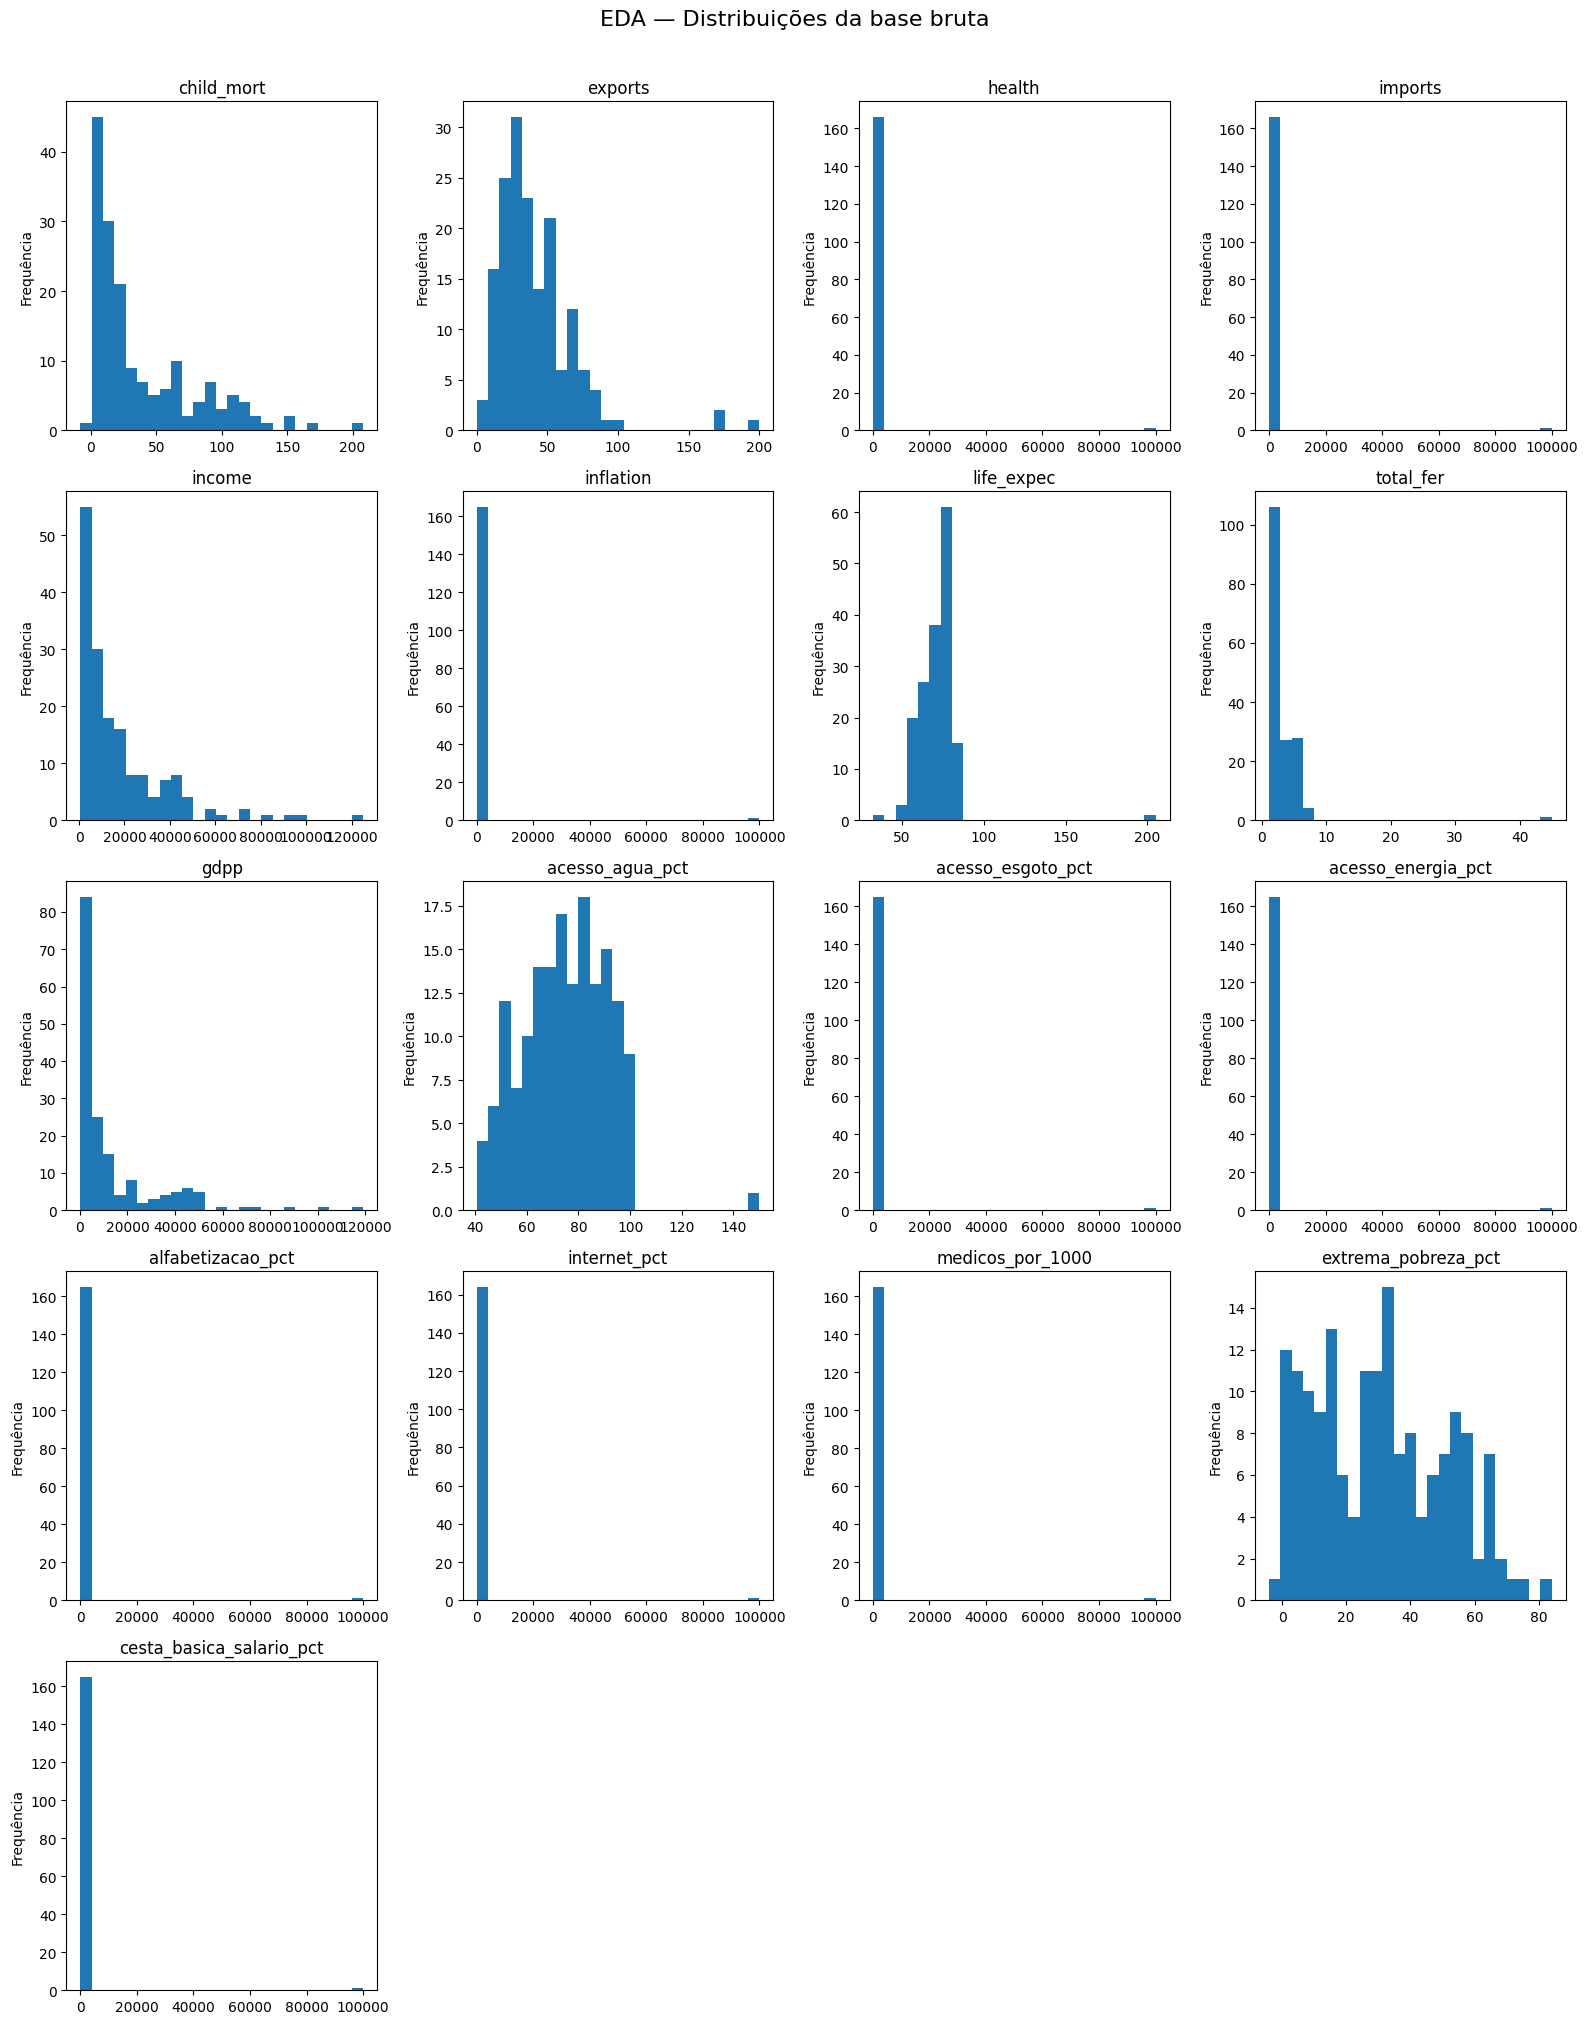

In [46]:
n = len(num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_cols):
    ax.hist(df_raw[col].dropna(), bins=25)
    ax.set_title(col)
    ax.set_ylabel("Frequência")

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("EDA — Distribuições da base bruta", y=1.01, fontsize=16)
fig.tight_layout()
plt.show()


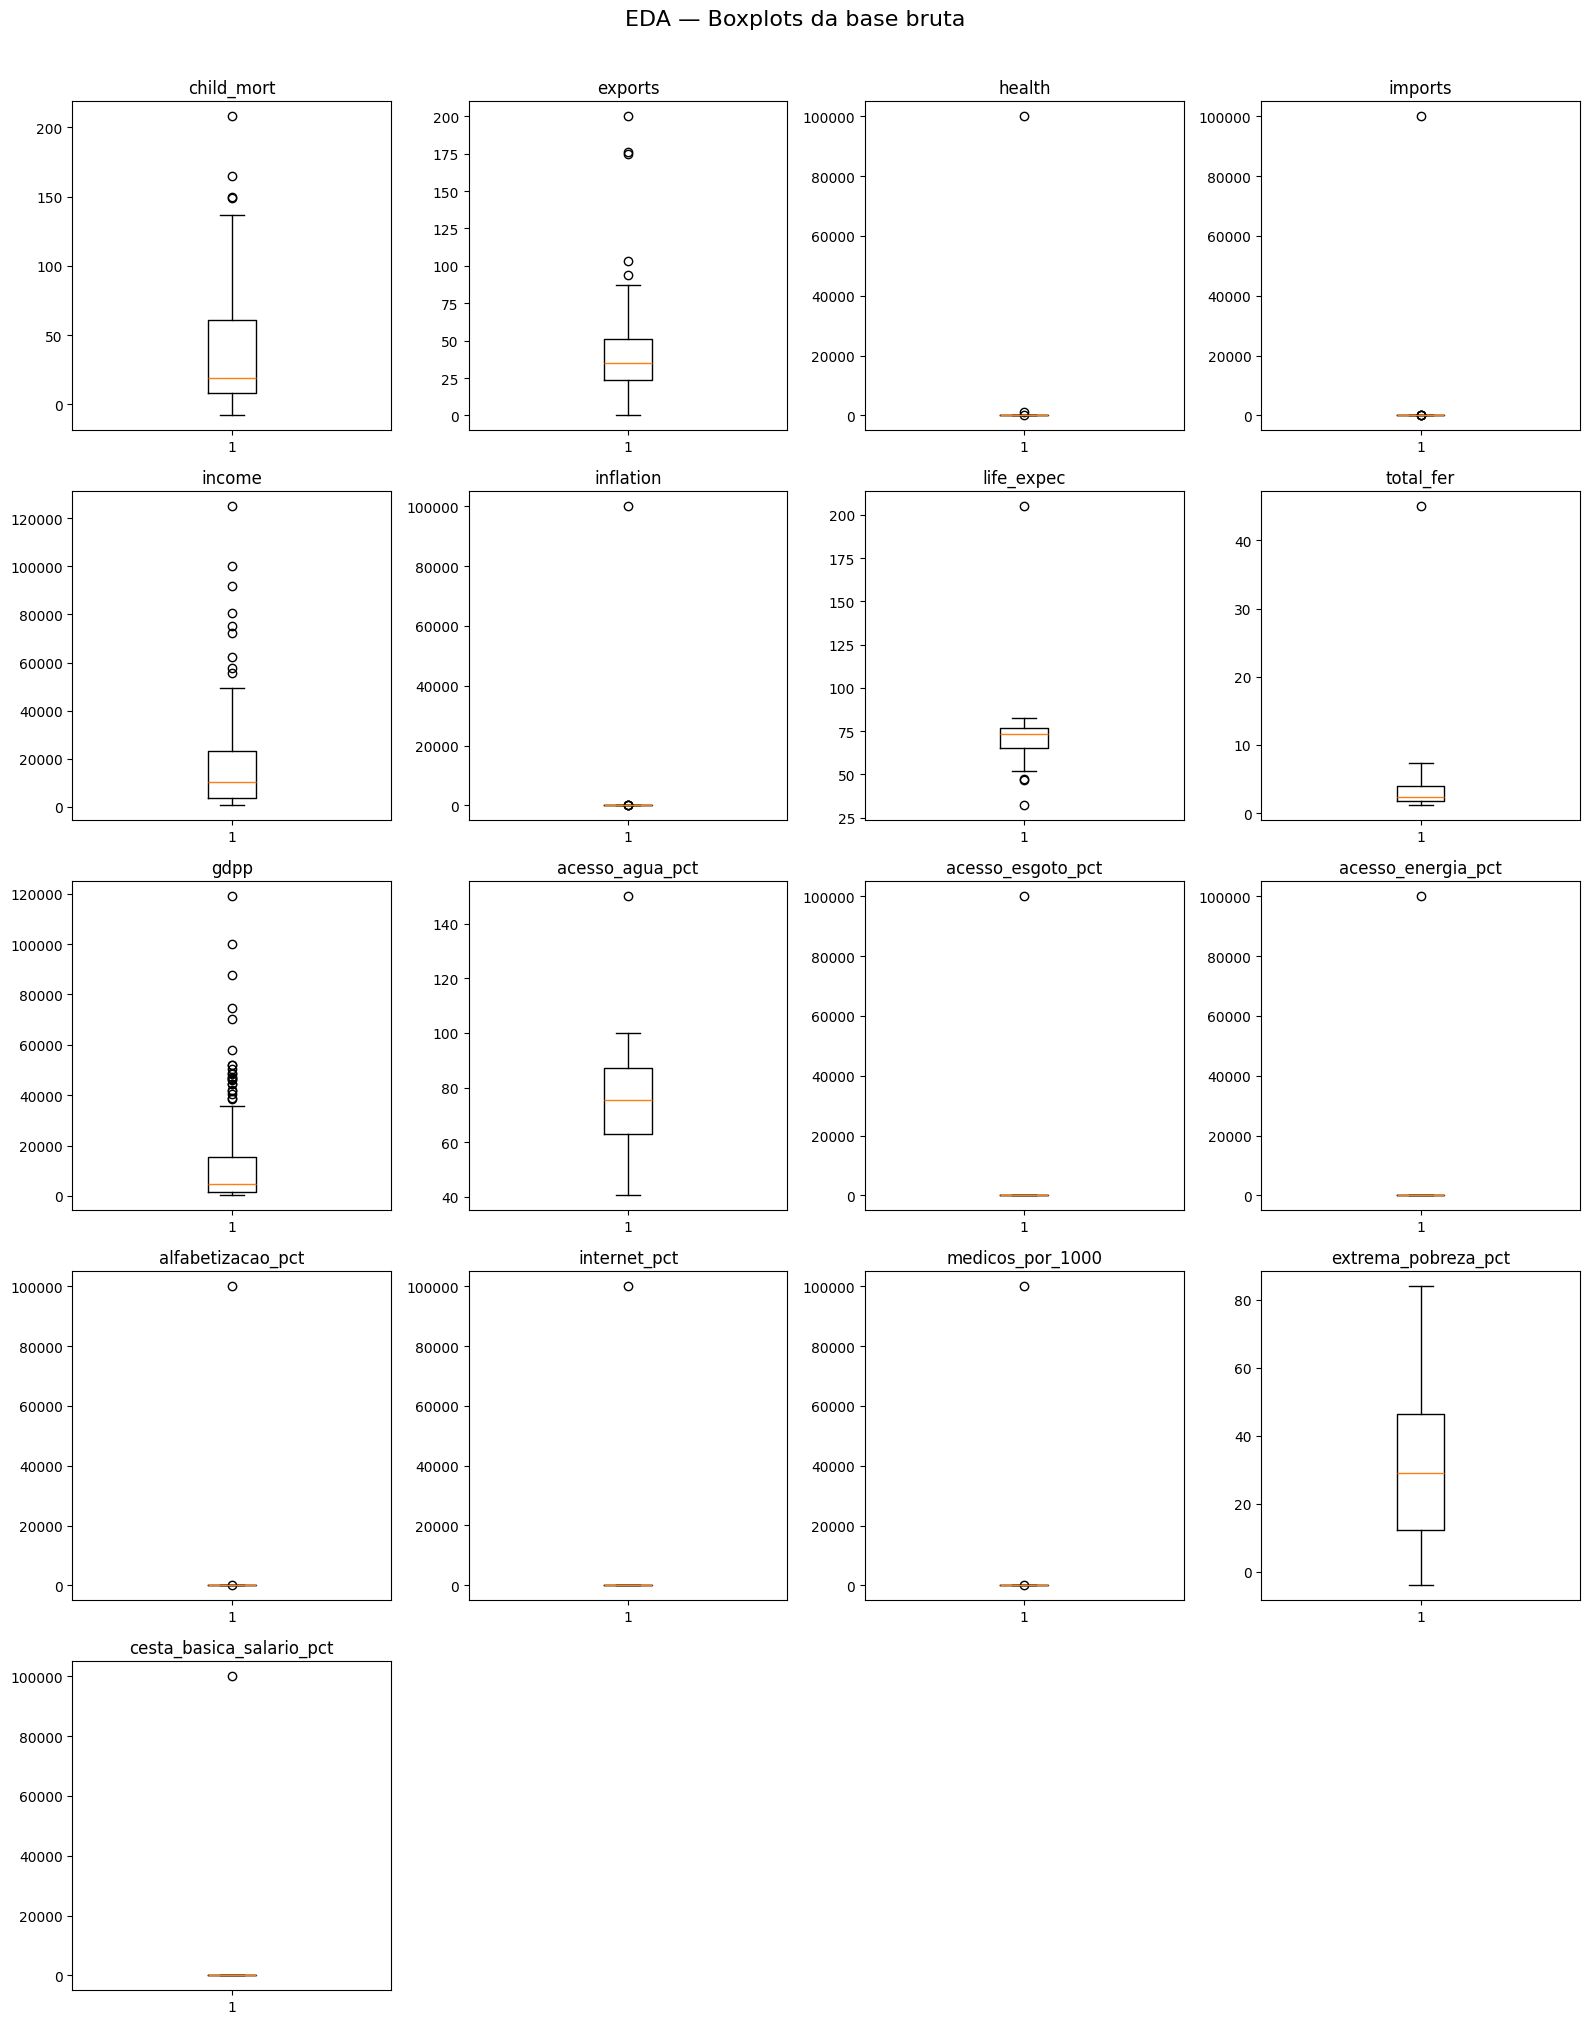

In [47]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_cols):
    ax.boxplot(df_raw[col].dropna())
    ax.set_title(col)

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("EDA — Boxplots da base bruta", y=1.01, fontsize=16)
fig.tight_layout()
plt.show()


In [48]:
outliers_raw = []

for col in num_cols:
    s = df_raw[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)

    outliers_raw.append({
        "variável": col,
        "skew": s.skew(),
        "Q1": q1,
        "mediana": s.median(),
        "Q3": q3,
        "limite_inf": lower,
        "limite_sup": upper,
        "n_outliers_IQR": int(mask.sum()),
        "%_outliers": round(mask.mean()*100, 2)
    })

outliers_raw = pd.DataFrame(outliers_raw).sort_values(
    "n_outliers_IQR", ascending=False
)

display(outliers_raw.round(3))


,variável,skew,Q1,mediana,Q3,limite_inf,limite_sup,n_outliers_IQR,%_outliers
8,gdpp,2.452,1365.000,4680.000,15300.000,-19537.500,36202.500,22,13.17
4,income,2.247,3545.000,10400.000,23000.000,-25637.500,52182.500,9,5.39
5,inflation,12.884,1.790,5.265,11.050,-12.100,24.940,5,3.01
3,imports,12.923,30.200,43.300,58.900,-12.850,101.950,5,2.99
1,exports,2.554,23.800,35.200,51.375,-17.562,92.738,5,3.01
0,child_mort,1.467,7.825,19.250,61.200,-72.238,141.262,4,2.41
6,life_expec,5.363,65.300,73.100,76.800,48.050,94.050,4,2.41
2,health,12.921,4.920,6.320,8.760,-0.840,14.520,3,1.80
12,alfabetizacao_pct,12.884,68.600,80.450,89.350,37.475,120.475,2,1.20
14,medicos_por_1000,12.884,1.272,2.415,3.608,-2.230,7.110,2,1.20


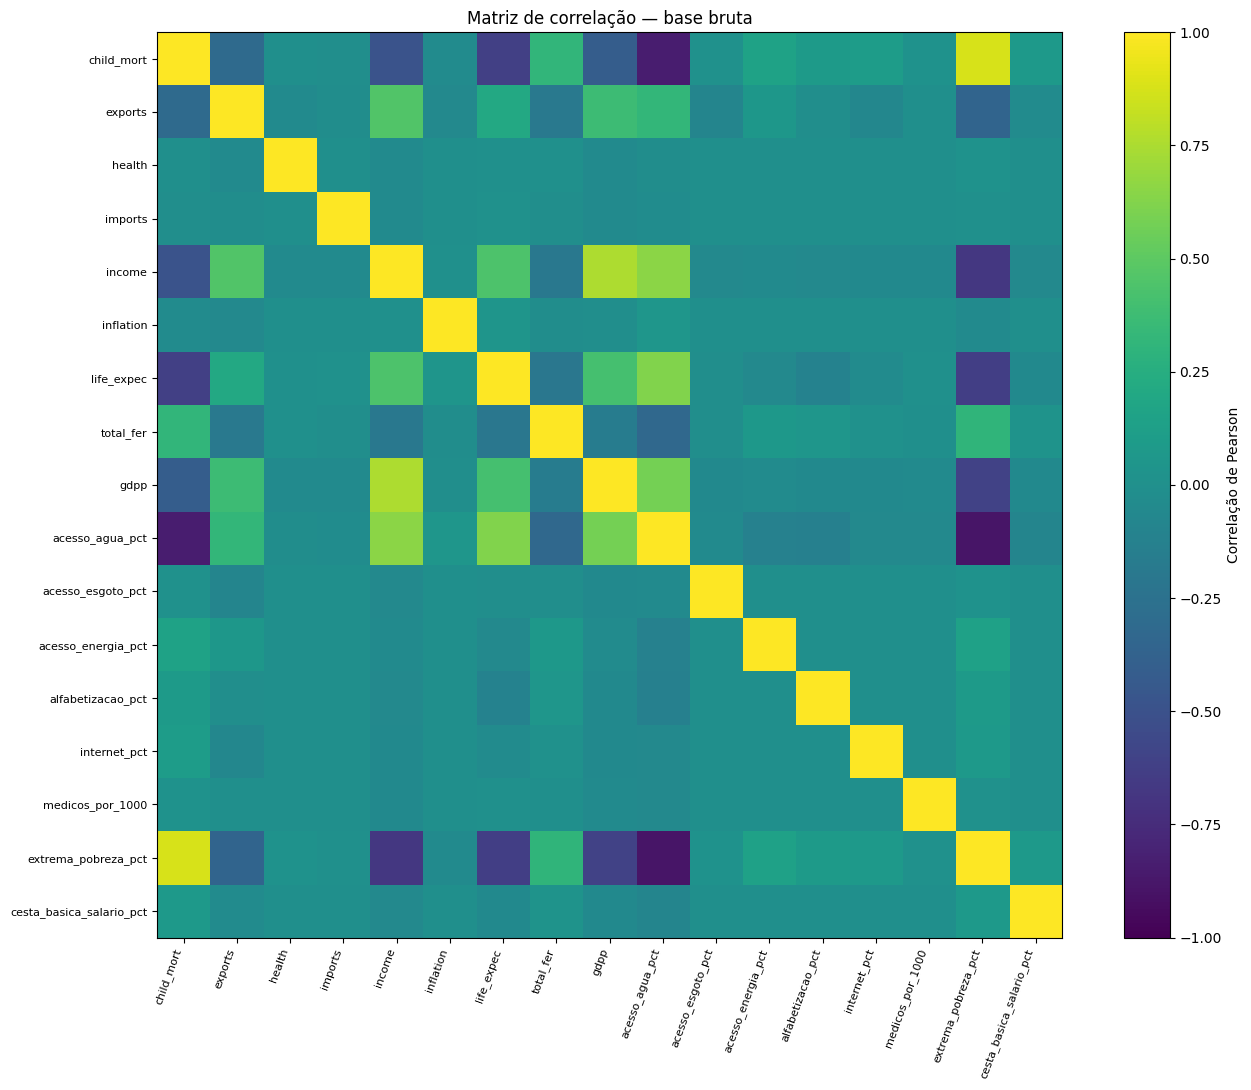

15 pares mais correlacionados:


correlação
acesso_agua_pct extrema_pobreza_pct   -0.889431
child_mort      extrema_pobreza_pct    0.877455
                acesso_agua_pct       -0.836095
income          gdpp                   0.756855
                extrema_pobreza_pct   -0.678658
                acesso_agua_pct        0.649174
life_expec      extrema_pobreza_pct   -0.626621
child_mort      life_expec            -0.620822
life_expec      acesso_agua_pct        0.619195
gdpp            extrema_pobreza_pct   -0.604363
                acesso_agua_pct        0.585002
child_mort      income                -0.486928
exports         income                 0.456758
income          life_expec             0.441041
child_mort      gdpp                  -0.412873

In [49]:
corr_raw = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr_raw, vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=70, ha="right", fontsize=8)
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols, fontsize=8)
ax.set_title("Matriz de correlação — base bruta")

fig.colorbar(im, ax=ax, label="Correlação de Pearson")
fig.tight_layout()
plt.show()

pares_corr = (
    corr_raw.where(np.triu(np.ones(corr_raw.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=np.abs, ascending=False)
)

print("15 pares mais correlacionados:")
display(pares_corr.head(15).to_frame("correlação"))


In [50]:
df = df_raw.copy()

df = df.replace(SENTINELAS, np.nan)

print("Faltantes após conversão das sentinelas:")
display(df.isna().sum().sort_values(ascending=False).to_frame("faltantes"))


Faltantes após conversão das sentinelas:


,faltantes
internet_pct,3
inflation,2
acesso_esgoto_pct,2
acesso_energia_pct,2
medicos_por_1000,2
cesta_basica_salario_pct,2
acesso_agua_pct,2
alfabetizacao_pct,2
gdpp,1
child_mort,1


In [51]:
DOMAIN_RULES = {
    "health": lambda s: (s < 0) | (s > 100),
    "child_mort": lambda s: s < 0,
    "life_expec": lambda s: (s <= 0) | (s > 120),
    "total_fer": lambda s: s < 0,
    "acesso_agua_pct": lambda s: (s < 0) | (s > 100),
    "acesso_esgoto_pct": lambda s: (s < 0) | (s > 100),
    "acesso_energia_pct": lambda s: (s < 0) | (s > 100),
    "alfabetizacao_pct": lambda s: (s < 0) | (s > 100),
    "internet_pct": lambda s: (s < 0) | (s > 100),
    "medicos_por_1000": lambda s: s < 0,
    "extrema_pobreza_pct": lambda s: (s < 0) | (s > 100),
    "cesta_basica_salario_pct": lambda s: s < 0,
}

invalid_report = []

for col, rule in DOMAIN_RULES.items():
    if col in df.columns:
        mask = rule(df[col]) & df[col].notna()
        invalid_report.append({
            "variável": col,
            "valores_invalidos": int(mask.sum())
        })
        df.loc[mask, col] = np.nan

invalid_report = pd.DataFrame(invalid_report)
display(invalid_report[invalid_report["valores_invalidos"] > 0])


,variável,valores_invalidos
0,health,1
1,child_mort,1
2,life_expec,1
4,acesso_agua_pct,1
7,alfabetizacao_pct,1
8,internet_pct,1
10,extrema_pobreza_pct,1


In [52]:
missing_after_clean = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "%": (df.isna().mean()*100).round(2)
}).sort_values("faltantes", ascending=False)

display(missing_after_clean[missing_after_clean["faltantes"] > 0])


,faltantes,%
internet_pct,4,2.4
acesso_agua_pct,3,1.8
alfabetizacao_pct,3,1.8
child_mort,2,1.2
extrema_pobreza_pct,2,1.2
health,2,1.2
acesso_esgoto_pct,2,1.2
inflation,2,1.2
life_expec,2,1.2
acesso_energia_pct,2,1.2


In [53]:
indicadores_info = []

for col in num_cols:
    s = df[col]
    indicadores_info.append({
        "indicador": col,
        "faltantes": int(s.isna().sum()),
        "%_faltantes": round(s.isna().mean()*100, 2),
        "mediana": s.median(),
        "média": s.mean(),
        "skew": s.skew(),
        "desvio": s.std(),
        "min": s.min(),
        "max": s.max(),
    })

indicadores_info = pd.DataFrame(indicadores_info)
display(indicadores_info.sort_values("%_faltantes"))


,indicador,faltantes,%_faltantes,mediana,média,skew,desvio,min,max
1,exports,1,0.6,35.20,41.285536,2.554363,28.108712,0.1090,200.0
3,imports,1,0.6,43.30,46.973891,2.030616,24.608350,0.0659,184.0
7,total_fer,1,0.6,2.41,3.206325,9.644343,3.598364,1.1500,45.0
4,income,1,0.6,10180.00,17233.271084,2.225507,19302.277458,609.0000,125000.0
8,gdpp,1,0.6,4670.00,13123.006024,2.420983,18810.392774,231.0000,119000.0
2,health,2,1.2,6.22,6.811576,0.706379,2.763073,1.8100,17.9
5,inflation,2,1.2,5.14,8.086218,5.313895,12.312484,-4.2100,104.0
0,child_mort,2,1.2,19.30,38.275758,1.468284,40.516716,2.6000,208.0
6,life_expec,2,1.2,73.10,70.460606,-0.957025,8.902711,32.1000,82.8
10,acesso_esgoto_pct,2,1.2,58.60,57.335758,-0.163695,24.711728,7.0000,100.0


In [54]:
FEATURES = ["child_mort", "health", "income", "exports"]

assert len(FEATURES) == 4, "O projeto exige exatamente 4 indicadores."
assert all(col in df.columns for col in FEATURES), "Há indicador inexistente na base."

print("Indicadores selecionados nesta versão:", FEATURES)


Indicadores selecionados nesta versão: ['child_mort', 'health', 'income', 'exports']


,child_mort,health,income,exports
child_mort,1.000,-0.195,-0.522,-0.314
health,-0.195,1.000,0.125,-0.111
income,-0.522,0.125,1.000,0.506
exports,-0.314,-0.111,0.506,1.000


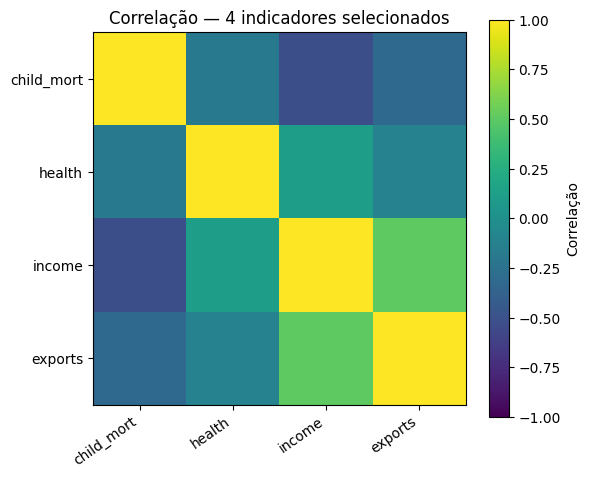

In [55]:
corr_features = df[FEATURES].corr()
display(corr_features.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_features, vmin=-1, vmax=1)
ax.set_xticks(range(4))
ax.set_xticklabels(FEATURES, rotation=35, ha="right")
ax.set_yticks(range(4))
ax.set_yticklabels(FEATURES)
ax.set_title("Correlação — 4 indicadores selecionados")
fig.colorbar(im, ax=ax, label="Correlação")
fig.tight_layout()
plt.show()


In [56]:
X_before_transform = df[FEATURES].copy()

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_before_transform),
    columns=FEATURES,
    index=df.index
)

print("Faltantes após imputação:", int(X_imputed.isna().sum().sum()))
display(X_imputed.describe().T.round(3))


Faltantes após imputação: 0


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.049,40.325,2.600,8.25,19.30,60.40,208.0
health,167.0,6.804,2.747,1.810,4.92,6.22,8.60,17.9
income,167.0,17191.036,19251.789,609.000,3545.00,10180.00,22800.00,125000.0
exports,167.0,41.249,28.028,0.109,23.80,35.20,51.35,200.0


In [57]:
skew_after_impute = X_imputed.skew().sort_values(ascending=False)
display(skew_after_impute.to_frame("skew"))

LOG_FEATURES = ["income", "exports"]

for col in LOG_FEATURES:
    if col in FEATURES:
        if (X_imputed[col] < 0).any():
            raise ValueError(
                f"{col} possui valores negativos; não aplique log1p sem revisar a regra."
            )

X_transformed = X_imputed.copy()

for col in LOG_FEATURES:
    if col in X_transformed.columns:
        X_transformed[col] = np.log1p(X_transformed[col])

print("Assimetria antes:")
display(X_imputed[FEATURES].skew().to_frame("skew_antes"))

print("Assimetria depois:")
display(X_transformed[FEATURES].skew().to_frame("skew_depois"))


,skew
exports,2.564705
income,2.235749
child_mort,1.486998
health,0.717689


Assimetria antes:


,skew_antes
child_mort,1.486998
health,0.717689
income,2.235749
exports,2.564705


Assimetria depois:


,skew_depois
child_mort,1.486998
health,0.717689
income,-0.251927
exports,-1.061801


In [58]:
outlier_model = []

for col in FEATURES:
    s = X_transformed[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    mask = (s < lower) | (s > upper)

    outlier_model.append({
        "indicador": col,
        "Q1": q1,
        "Q3": q3,
        "limite_inf": lower,
        "limite_sup": upper,
        "n_outliers": int(mask.sum()),
        "%_outliers": round(mask.mean()*100, 2)
    })

outlier_model = pd.DataFrame(outlier_model)
display(outlier_model.round(3))


,indicador,Q1,Q3,limite_inf,limite_sup,n_outliers,%_outliers
0,child_mort,8.250,60.400,-69.975,138.625,4,2.40
1,health,4.920,8.600,-0.600,14.120,2,1.20
2,income,8.172,10.035,5.379,12.828,0,0.00
3,exports,3.211,3.958,2.090,5.079,6,3.59


In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=FEATURES,
    index=df.index
)

print("Médias após StandardScaler:")
display(X_scaled_df.mean().round(6).to_frame("média"))

print("Desvios-padrão após StandardScaler:")
display(X_scaled_df.std(ddof=0).round(6).to_frame("desvio"))

display(X_scaled_df.head())


Médias após StandardScaler:


,média
child_mort,-0.0
health,0.0
income,0.0
exports,0.0


Desvios-padrão após StandardScaler:


,desvio
child_mort,1.0
health,1.0
income,1.0
exports,1.0


,child_mort,health,income,exports
0,1.297166,0.283146,-1.424942,-1.760373
1,-0.533490,-0.092917,0.064903,-0.284388
2,-0.267348,-0.961880,0.279225,0.182236
3,2.013510,-1.443825,-0.361488,0.904119
4,-0.690190,-0.282775,0.600682,0.434506


,k,inercia,silhueta
0,2,410.7622,0.4006
1,3,319.4886,0.2945
2,4,273.8516,0.2625
3,5,237.1128,0.2750
4,6,208.3073,0.2874
5,7,187.2197,0.2633
6,8,171.5309,0.2598


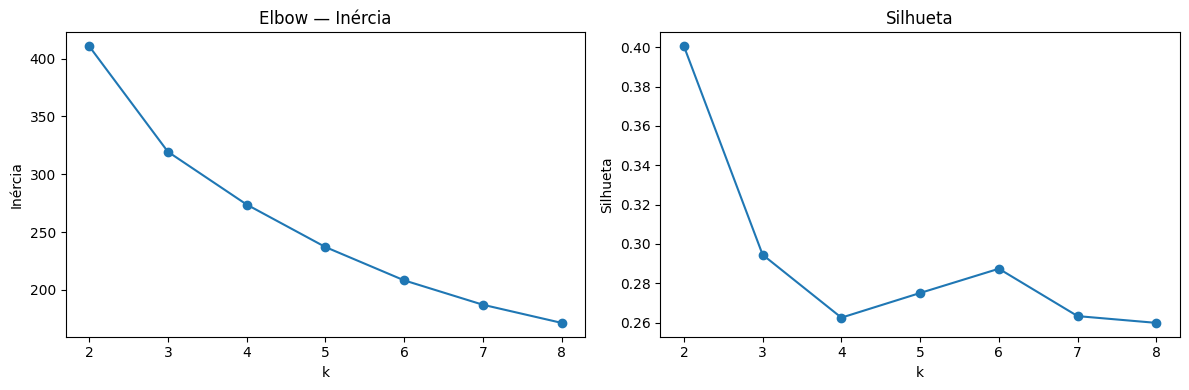

In [60]:
K_RANGE = range(2, 9)

inertias = []
silhouettes = []

for k in K_RANGE:
    model = KMeans(n_clusters=k, n_init=50, random_state=SEED)
    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

k_eval = pd.DataFrame({
    "k": list(K_RANGE),
    "inercia": inertias,
    "silhueta": silhouettes
})

display(k_eval.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_eval["k"], k_eval["inercia"], marker="o")
axes[0].set_title("Elbow — Inércia")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")

axes[1].plot(k_eval["k"], k_eval["silhueta"], marker="o")
axes[1].set_title("Silhueta")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhueta")

fig.tight_layout()
plt.show()


In [61]:
K_FINAL = int(k_eval.loc[k_eval["silhueta"].idxmax(), "k"])

print("k definitivo:", K_FINAL)


k definitivo: 2


In [62]:
kmeans = KMeans(
    n_clusters=K_FINAL,
    n_init=50,
    random_state=SEED
)

labels_kmeans = kmeans.fit_predict(X_scaled)

print("Métricas K-Means")
print("Silhueta:", round(silhouette_score(X_scaled, labels_kmeans), 4))
print("Calinski-Harabasz:", round(calinski_harabasz_score(X_scaled, labels_kmeans), 4))
print("Davies-Bouldin:", round(davies_bouldin_score(X_scaled, labels_kmeans), 4))

print("\nTamanho dos clusters:")
display(pd.Series(labels_kmeans).value_counts().sort_index().to_frame("n"))


Métricas K-Means
Silhueta: 0.4006
Calinski-Harabasz: 103.3304
Davies-Bouldin: 1.0457

Tamanho dos clusters:


,n
0,46
1,121


In [63]:
resultado = df[["country"] + FEATURES].copy()
resultado["cluster_kmeans"] = labels_kmeans

perfil_kmeans = resultado.groupby("cluster_kmeans")[FEATURES].median()
perfil_kmeans["n_países"] = resultado.groupby("cluster_kmeans").size()

display(perfil_kmeans.round(3))


,child_mort,health,income,exports,n_países
cluster_kmeans,,,,,
0,90.2,5.235,1850.0,21.45,46
1,14.0,6.840,16200.0,42.40,121


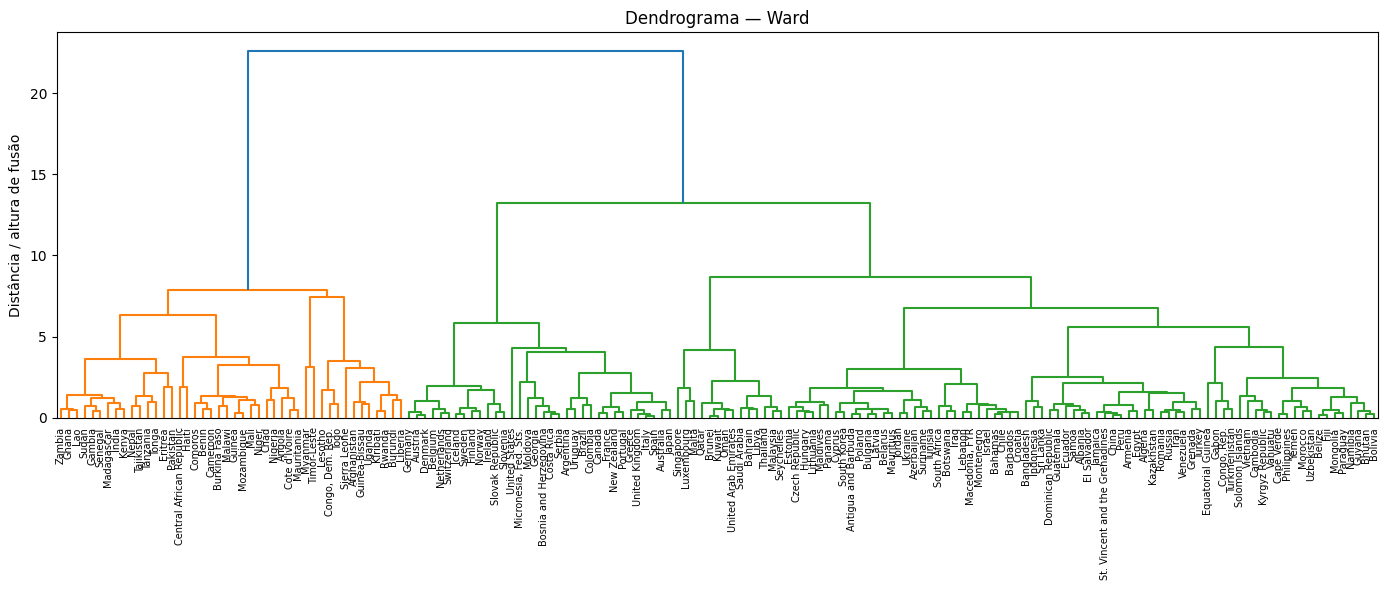

In [64]:
Z = linkage(X_scaled, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    labels=df["country"].values if "country" in df.columns else None,
    leaf_rotation=90,
    leaf_font_size=7,
    ax=ax
)
ax.set_title("Dendrograma — Ward")
ax.set_ylabel("Distância / altura de fusão")
plt.tight_layout()
plt.show()


In [65]:
ward_eval = []

for k in range(2, 9):
    labels_ward_k = fcluster(Z, t=k, criterion="maxclust")
    ward_eval.append({
        "k": k,
        "silhueta": silhouette_score(X_scaled, labels_ward_k),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels_ward_k),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels_ward_k)
    })

ward_eval = pd.DataFrame(ward_eval)
display(ward_eval.round(4))


,k,silhueta,calinski_harabasz,davies_bouldin
0,2,0.4051,102.4763,1.0364
1,3,0.3016,86.7818,1.1043
2,4,0.2818,72.0529,1.0846
3,5,0.2735,65.0550,1.2806
4,6,0.2750,61.8687,1.0867
5,7,0.2088,59.8037,1.1768
6,8,0.2075,58.7955,1.1592


In [66]:
labels_ward = fcluster(Z, t=K_FINAL, criterion="maxclust")

ari = adjusted_rand_score(labels_kmeans, labels_ward)

print("Comparação para o mesmo k:")
print("Silhueta K-Means:", round(silhouette_score(X_scaled, labels_kmeans), 4))
print("Silhueta Ward:", round(silhouette_score(X_scaled, labels_ward), 4))
print("ARI K-Means × Ward:", round(ari, 4))

print("\nTabela de concordância:")
display(pd.crosstab(labels_kmeans, labels_ward))


Comparação para o mesmo k:
Silhueta K-Means: 0.4006
Silhueta Ward: 0.4051
ARI K-Means × Ward: 0.9502

Tabela de concordância:


col_0,1,2
row_0,,
0,44,2
1,0,121


In [67]:
perfil_final = resultado.groupby("cluster_kmeans")[FEATURES].agg(
    ["median", "mean", "min", "max"]
)

display(perfil_final.round(3))


child_mort                      health                     \
                   median    mean   min    max median   mean   min   max   
cluster_kmeans                                                             
0                    90.2  92.311  17.4  208.0  5.235  6.157  1.97  13.1   
1                    14.0  18.012   2.6  111.0  6.840  7.065  1.81  17.9   

                 income                              exports                  \
                 median       mean     min       max  median    mean     min   
cluster_kmeans                                                                 
0                1850.0   2261.178   609.0    5900.0   21.45  22.993   0.109   
1               16200.0  22801.405  1780.0  125000.0   42.40  48.298  10.700   

                       
                  max  
cluster_kmeans         
0                62.3  
1               200.0

In [68]:
for cluster, grupo in resultado.groupby("cluster_kmeans"):
    print(f"\nCLUSTER {cluster} — {len(grupo)} países")
    display(
        grupo[["country"] + FEATURES]
        .sort_values("country")
        .reset_index(drop=True)
    )



CLUSTER 0 — 46 países


,country,child_mort,health,income,exports
0,Afghanistan,90.2,7.58,1610.0,10.000
1,Angola,119.0,2.85,5900.0,62.300
2,Bangladesh,49.4,3.52,NaN,16.000
3,Benin,111.0,4.10,1820.0,23.800
4,Burkina Faso,116.0,6.74,1430.0,19.200
5,Burundi,93.6,11.60,764.0,8.920
6,Cameroon,108.0,5.13,2660.0,22.200
7,Central African Republic,149.0,3.98,888.0,11.800
8,Chad,150.0,4.53,1930.0,36.800
9,Comoros,88.2,4.51,1410.0,16.500



CLUSTER 1 — 121 países


,country,child_mort,health,income,exports
0,Albania,16.6,6.55,9930.0,28.0
1,Algeria,27.3,4.17,12900.0,38.4
2,Antigua and Barbuda,10.3,6.03,19100.0,45.5
3,Argentina,14.5,8.10,18700.0,18.9
4,Armenia,18.1,4.40,6700.0,20.8
...,...,...,...,...,...
116,Uruguay,10.6,8.35,17100.0,26.3
117,Uzbekistan,36.3,5.81,4240.0,31.7
118,Vanuatu,29.2,5.25,2950.0,46.6
119,Venezuela,17.1,4.91,16500.0,28.5


In [69]:
OUTPUT_DIR = Path("resultados_projeto1")
OUTPUT_DIR.mkdir(exist_ok=True)

eda_raw.to_csv(OUTPUT_DIR / "01_eda_descritiva_bruta.csv", encoding="utf-8-sig")
outliers_raw.to_csv(OUTPUT_DIR / "02_outliers_eda.csv", index=False, encoding="utf-8-sig")
indicadores_info.to_csv(OUTPUT_DIR / "03_indicadores_info.csv", index=False, encoding="utf-8-sig")
k_eval.to_csv(OUTPUT_DIR / "04_kmeans_elbow_silhueta.csv", index=False, encoding="utf-8-sig")
ward_eval.to_csv(OUTPUT_DIR / "05_ward_avaliacao.csv", index=False, encoding="utf-8-sig")
perfil_kmeans.to_csv(OUTPUT_DIR / "06_perfil_kmeans.csv", encoding="utf-8-sig")
resultado.to_csv(OUTPUT_DIR / "07_paises_clusters.csv", index=False, encoding="utf-8-sig")

print("Resultados exportados para:", OUTPUT_DIR.resolve())


Resultados exportados para: /content/resultados_projeto1


In [70]:
audit_rows = []

for idx in df_raw.index:
    country = df_raw.loc[idx, "country"]

    for col in FEATURES:
        original = df_raw.loc[idx, col]
        cleaned = df.loc[idx, col]
        imputed = X_imputed.loc[idx, col]

        original_missing = pd.isna(original)
        converted_to_missing = (not original_missing) and pd.isna(cleaned)
        imputed_value = pd.isna(cleaned) and pd.notna(imputed)

        if original_missing:
            tipo = "NaN original → imputado"
        elif converted_to_missing:
            tipo = "valor inválido/sentinela → imputado"
        else:
            tipo = "sem alteração de limpeza"

        audit_rows.append({
            "country": country,
            "indicador": col,
            "valor_original": original,
            "valor_pos_limpeza": cleaned,
            "valor_usado_modelo": imputed,
            "tratamento": tipo
        })

auditoria = pd.DataFrame(audit_rows)

print("Resumo da auditoria:")
display(
    auditoria.groupby("tratamento")
    .size()
    .rename("quantidade")
    .to_frame()
)

print("\nSomente observações alteradas/imputadas:")
display(
    auditoria[auditoria["tratamento"] != "sem alteração de limpeza"]
    .sort_values(["country", "indicador"])
    .reset_index(drop=True)
)


Resumo da auditoria:


,quantidade
tratamento,
NaN original → imputado,2
sem alteração de limpeza,662
valor inválido/sentinela → imputado,4



Somente observações alteradas/imputadas:


,country,indicador,valor_original,valor_pos_limpeza,valor_usado_modelo,tratamento
0,Bangladesh,income,99999.0,NaN,10180.00,valor inválido/sentinela → imputado
1,Chile,child_mort,-8.0,NaN,19.30,valor inválido/sentinela → imputado
2,Guatemala,health,99999.0,NaN,6.22,valor inválido/sentinela → imputado
3,Philippines,exports,NaN,NaN,35.20,NaN original → imputado
4,Poland,health,999.0,NaN,6.22,valor inválido/sentinela → imputado
5,Tanzania,child_mort,NaN,NaN,19.30,NaN original → imputado


## Como ler a auditoria

A coluna `valor_original` mostra o dado que veio da base.

A coluna `valor_pos_limpeza` mostra o resultado depois de:
- converter sentinelas;
- transformar valores inválidos em `NaN`.

A coluna `valor_usado_modelo` mostra o valor efetivamente utilizado pelo algoritmo depois da imputação.



In [71]:
modelo_final = KMeans(
    n_clusters=2,
    n_init=50,
    random_state=SEED
)

labels_final = modelo_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, labels_final)
ch_final = calinski_harabasz_score(X_scaled, labels_final)
db_final = davies_bouldin_score(X_scaled, labels_final)

Z_final = linkage(X_scaled, method="ward", metric="euclidean")
labels_ward_final = fcluster(Z_final, t=2, criterion="maxclust")
sil_ward_final = silhouette_score(X_scaled, labels_ward_final)
ari_final = adjusted_rand_score(labels_final, labels_ward_final)

metricas_finais = pd.DataFrame({
    "método": ["K-Means", "Ward"],
    "k": [2, 2],
    "silhueta": [sil_final, sil_ward_final],
    "ARI_vs_outro": [ari_final, ari_final]
})

display(metricas_finais.round(4))
print("Calinski-Harabasz K-Means:", round(ch_final, 4))
print("Davies-Bouldin K-Means:", round(db_final, 4))


,método,k,silhueta,ARI_vs_outro
0,K-Means,2,0.4006,0.9502
1,Ward,2,0.4051,0.9502


Calinski-Harabasz K-Means: 103.3304
Davies-Bouldin K-Means: 1.0457


In [72]:
resultado_final = df_raw[["country"] + FEATURES].copy()
resultado_final["cluster"] = labels_final

perfil_mediano = resultado_final.groupby("cluster")[FEATURES].median()
tamanho = resultado_final.groupby("cluster").size().rename("n_países")
perfil_mediano = perfil_mediano.join(tamanho)

display(perfil_mediano.round(3))

perfil_z = pd.DataFrame(X_scaled, columns=FEATURES, index=df_raw.index)
perfil_z["cluster"] = labels_final

print("\nCentro médio dos clusters no espaço padronizado:")
display(perfil_z.groupby("cluster")[FEATURES].mean().round(3))


,child_mort,health,income,exports,n_países
cluster,,,,,
0,90.2,5.235,1860.0,21.45,46
1,13.8,6.870,16200.0,42.40,121



Centro médio dos clusters no espaço padronizado:


,child_mort,health,income,exports
cluster,,,,
0,1.310,-0.236,-1.248,-0.849
1,-0.498,0.090,0.475,0.323


In [73]:
med = perfil_mediano.copy()

cluster_vulneravel = med["child_mort"].idxmax()
cluster_maior_capacidade = med["child_mort"].idxmin()

nomes_perfil = {
    cluster_vulneravel: "Maior vulnerabilidade socioeconômica e sanitária",
    cluster_maior_capacidade: "Menor vulnerabilidade relativa / maior capacidade econômica"
}

resultado_final["perfil"] = resultado_final["cluster"].map(nomes_perfil)

print("Perfis definidos:")
for cluster, nome in nomes_perfil.items():
    print(f"Cluster {cluster}: {nome}")

print("\nQuantidade por perfil:")
display(
    resultado_final.groupby(["cluster", "perfil"])
    .size()
    .rename("n_países")
    .reset_index()
)

print("\nPerfil mediano:")
perfil_nomeado = resultado_final.groupby("perfil")[FEATURES].median()
perfil_nomeado["n_países"] = resultado_final.groupby("perfil").size()
display(perfil_nomeado.round(3))


Perfis definidos:
Cluster 0: Maior vulnerabilidade socioeconômica e sanitária
Cluster 1: Menor vulnerabilidade relativa / maior capacidade econômica

Quantidade por perfil:


,cluster,perfil,n_países
0,0,Maior vulnerabilidade socioeconômica e sanitária,46
1,1,Menor vulnerabilidade relativa / maior capacid...,121



Perfil mediano:


,child_mort,health,income,exports,n_países
perfil,,,,,
Maior vulnerabilidade socioeconômica e sanitária,90.2,5.235,1860.0,21.45,46
Menor vulnerabilidade relativa / maior capacidade econômica,13.8,6.870,16200.0,42.40,121


# Interpretação Formal dos Clusters

### Perfil A — Maior vulnerabilidade socioeconômica e sanitária

Este perfil é caracterizado principalmente por **maior mortalidade infantil e menor renda**, acompanhado pelas demais diferenças observadas nos indicadores selecionados.

Para a ONG, este grupo representa países que podem demandar estratégias de ajuda mais concentradas em necessidades básicas, saúde e redução de vulnerabilidades.

### Perfil B — Menor vulnerabilidade relativa / maior capacidade econômica

Este perfil apresenta **menor mortalidade infantil e maior renda**, com diferenças também observadas em `health` e `exports`.

Para a ONG, o grupo pode demandar estratégias diferentes das aplicadas ao Perfil A, com maior foco em ações específicas e/ou de fortalecimento, conforme a disponibilidade do fundo.

> A classificação não representa um ranking de países. Ela representa dois **perfis estatísticos** encontrados pelo algoritmo.


In [74]:
for perfil, grupo in resultado_final.groupby("perfil"):
    print("=" * 80)
    print(perfil)
    print(f"Total: {len(grupo)} países")
    display(
        grupo[["country"] + FEATURES]
        .sort_values("country")
        .reset_index(drop=True)
    )


Maior vulnerabilidade socioeconômica e sanitária
Total: 46 países


,country,child_mort,health,income,exports
0,Afghanistan,90.2,7.58,1610,10.000
1,Angola,119.0,2.85,5900,62.300
2,Bangladesh,49.4,3.52,99999,16.000
3,Benin,111.0,4.10,1820,23.800
4,Burkina Faso,116.0,6.74,1430,19.200
5,Burundi,93.6,11.60,764,8.920
6,Cameroon,108.0,5.13,2660,22.200
7,Central African Republic,149.0,3.98,888,11.800
8,Chad,150.0,4.53,1930,36.800
9,Comoros,88.2,4.51,1410,16.500


Menor vulnerabilidade relativa / maior capacidade econômica
Total: 121 países


,country,child_mort,health,income,exports
0,Albania,16.6,6.55,9930,28.0
1,Algeria,27.3,4.17,12900,38.4
2,Antigua and Barbuda,10.3,6.03,19100,45.5
3,Argentina,14.5,8.10,18700,18.9
4,Armenia,18.1,4.40,6700,20.8
...,...,...,...,...,...
116,Uruguay,10.6,8.35,17100,26.3
117,Uzbekistan,36.3,5.81,4240,31.7
118,Vanuatu,29.2,5.25,2950,46.6
119,Venezuela,17.1,4.91,16500,28.5


In [75]:
OUTPUT_FINAL = Path("resultados_projeto1_final")
OUTPUT_FINAL.mkdir(exist_ok=True)

auditoria.to_csv(
    OUTPUT_FINAL / "01_auditoria_valores.csv",
    index=False,
    encoding="utf-8-sig"
)

resultado_final.to_csv(
    OUTPUT_FINAL / "02_paises_perfis_finais.csv",
    index=False,
    encoding="utf-8-sig"
)

perfil_nomeado.to_csv(
    OUTPUT_FINAL / "03_perfil_mediano_final.csv",
    encoding="utf-8-sig"
)

metricas_finais.to_csv(
    OUTPUT_FINAL / "04_metricas_finais.csv",
    index=False,
    encoding="utf-8-sig"
)

k_eval.to_csv(
    OUTPUT_FINAL / "05_kmeans_elbow_silhueta.csv",
    index=False,
    encoding="utf-8-sig"
)

ward_eval.to_csv(
    OUTPUT_FINAL / "06_ward_avaliacao.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos finais exportados para:", OUTPUT_FINAL.resolve())


Arquivos finais exportados para: /content/resultados_projeto1_final
